### Notebook to explore SOCATv2025 independent validation

In [22]:
import pandas as pd

df = pd.read_csv(
    "/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/MODEL_SOCAT_ONLY_OBS_v2/models/independent_predictions/pco2_independent_validation_predictions.csv"
)

In [23]:
df

,month_center,latitude,longitude,depth,MLD,ARMOR3D_temperature,ARMOR3D_salinity,fco2_rec_median,SOCAT_temperature,SOCAT_salinity,...,pco2_pred_model_21,pco2_pred_model_22,pco2_pred_model_23,pco2_pred_model_24,pco2_pred_model_25,pco2_pred_model_26,pco2_pred_model_27,pco2_pred_model_28,pco2_pred_model_29,pco2_pred_model_30
0,1997-12-31 23:59:59.999999999,-77.5,164.5,0.0,15.000000,-1.550501,34.466503,169.8655,-0.9800,34.3900,...,330.52173,214.11043,245.08296,257.43964,270.65140,207.85756,193.00719,214.83205,240.27444,232.66780
1,1997-12-31 23:59:59.999999999,-77.5,172.5,0.0,17.625000,-0.308501,34.375500,289.2620,-1.3950,34.1650,...,392.93230,322.65717,345.40347,340.70700,361.42197,315.04556,348.63727,311.82806,362.05518,358.91608
2,1997-12-31 23:59:59.999999999,-77.5,174.5,0.0,15.149963,-0.193501,34.370250,291.7110,-1.1800,34.2900,...,323.74698,322.26935,322.20618,277.40600,312.21100,309.65780,283.99460,290.10083,292.11850,319.65457
3,1997-12-31 23:59:59.999999999,-76.5,164.5,0.0,15.650024,-1.052501,34.476500,163.8340,-1.4500,34.2300,...,335.32166,277.65192,284.30734,271.02148,280.26926,264.93896,253.46150,272.96722,273.45465,268.43112
4,1997-12-31 23:59:59.999999999,-76.5,166.5,0.0,15.000000,-0.749501,34.399750,182.9360,-1.3400,34.3200,...,320.36902,216.19273,245.59972,236.44568,275.41640,189.02118,168.12059,240.84193,234.44536,214.94481
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
856,2023-03-31 23:59:59.999999999,-38.5,-54.5,0.0,13.949951,21.056751,33.608253,350.9380,13.7370,33.5330,...,352.57300,366.53647,353.11856,357.74835,346.63632,358.47714,374.12800,371.86044,376.28586,377.37863
857,2023-03-31 23:59:59.999999999,-38.5,-52.5,0.0,15.049988,23.233250,34.173750,388.4040,23.3975,35.9815,...,375.15912,372.63050,367.99140,366.30710,375.36627,373.34890,366.44604,381.32970,371.97083,377.98477
858,2023-03-31 23:59:59.999999999,-37.5,-54.5,0.0,13.199951,21.515750,33.237750,331.5380,18.1930,33.7035,...,382.23593,383.83760,372.79180,357.90080,370.17215,369.62698,381.98767,386.02180,384.29260,385.24557
859,2023-03-31 23:59:59.999999999,-37.5,-52.5,0.0,15.000000,23.269749,33.979500,394.7080,22.6440,32.7810,...,369.50977,338.02454,355.38425,371.90400,335.83510,325.02438,347.63788,365.74220,386.45940,370.40482


Cluster → Representative Year:
{0: 1997, 52: 2004, 362: 2006, 449: 2008, 201: 2009, 387: 2012, 247: 2014, 308: 2017, 369: 2017, 170: 2019, 24: 2020, 120: 2023}


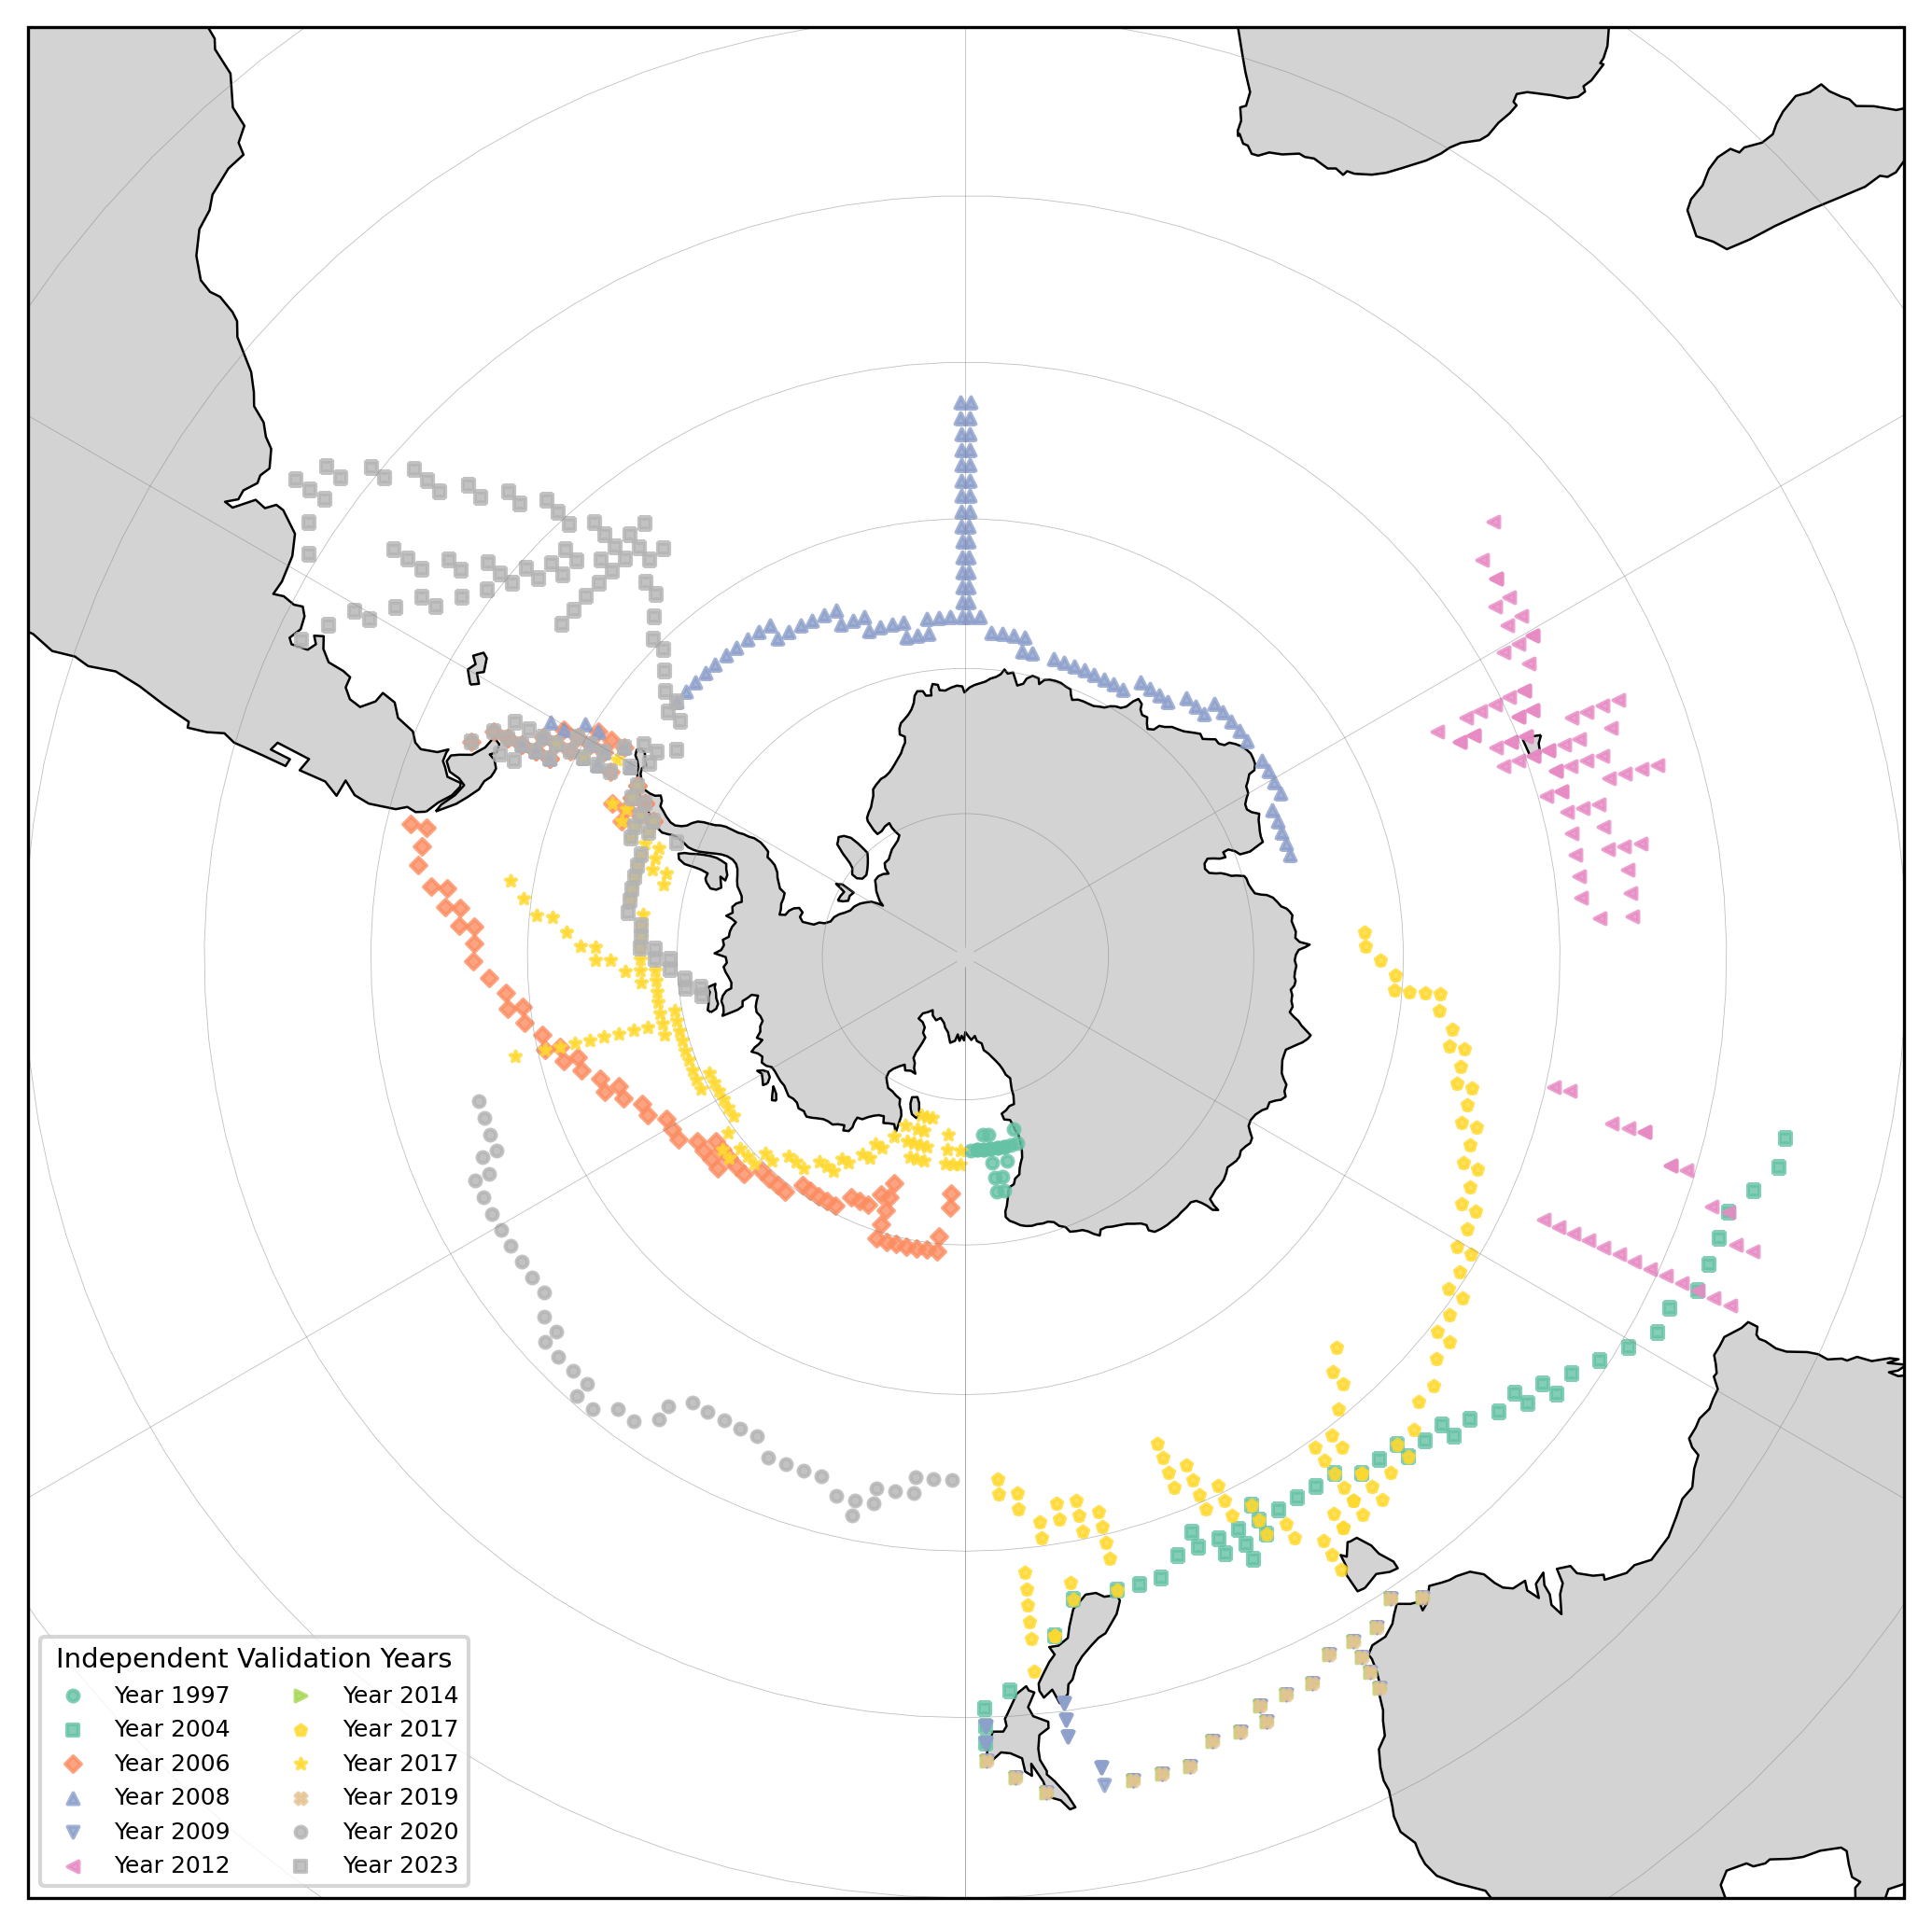

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Use unique clusters
clusters = df["cluster"].unique()
n_clusters = len(clusters)

# Compute representative year per cluster (median)
cluster_years = {
    cl: int(df[df["cluster"] == cl]["year"].median())
    for cl in clusters
}

print("Cluster → Representative Year:")
print(cluster_years)

# Set up map
fig = plt.figure(figsize=(7, 7), dpi=300)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -30], crs=ccrs.PlateCarree())

# Add base features
ax.coastlines(resolution='110m', linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.gridlines(draw_labels=False, linewidth=0.2, color='gray', alpha=0.5)

# Colors & markers
colors = plt.cm.Set2(np.linspace(0, 1, n_clusters))
markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'X']

# Plot clusters
for i, cl in enumerate(clusters):
    df_cl = df[df['cluster'] == cl]

    year_label = cluster_years[cl]

    ax.scatter(
        df_cl['longitude'],
        df_cl['latitude'],
        s=8,
        label=f"Year {year_label}",
        color=colors[i % len(colors)],
        marker=markers[i % len(markers)],
        transform=ccrs.PlateCarree(),
        zorder=2,
        alpha=0.8
    )

# Legend
ax.legend(
    title="Independent Validation Years",
    loc='lower left',
    fontsize=6,
    title_fontsize=7,
    ncol=2,
    frameon=True
)

plt.tight_layout()
plt.savefig("figs/independent_validation_clusters_map_years.png", dpi=300, bbox_inches='tight')
plt.show()


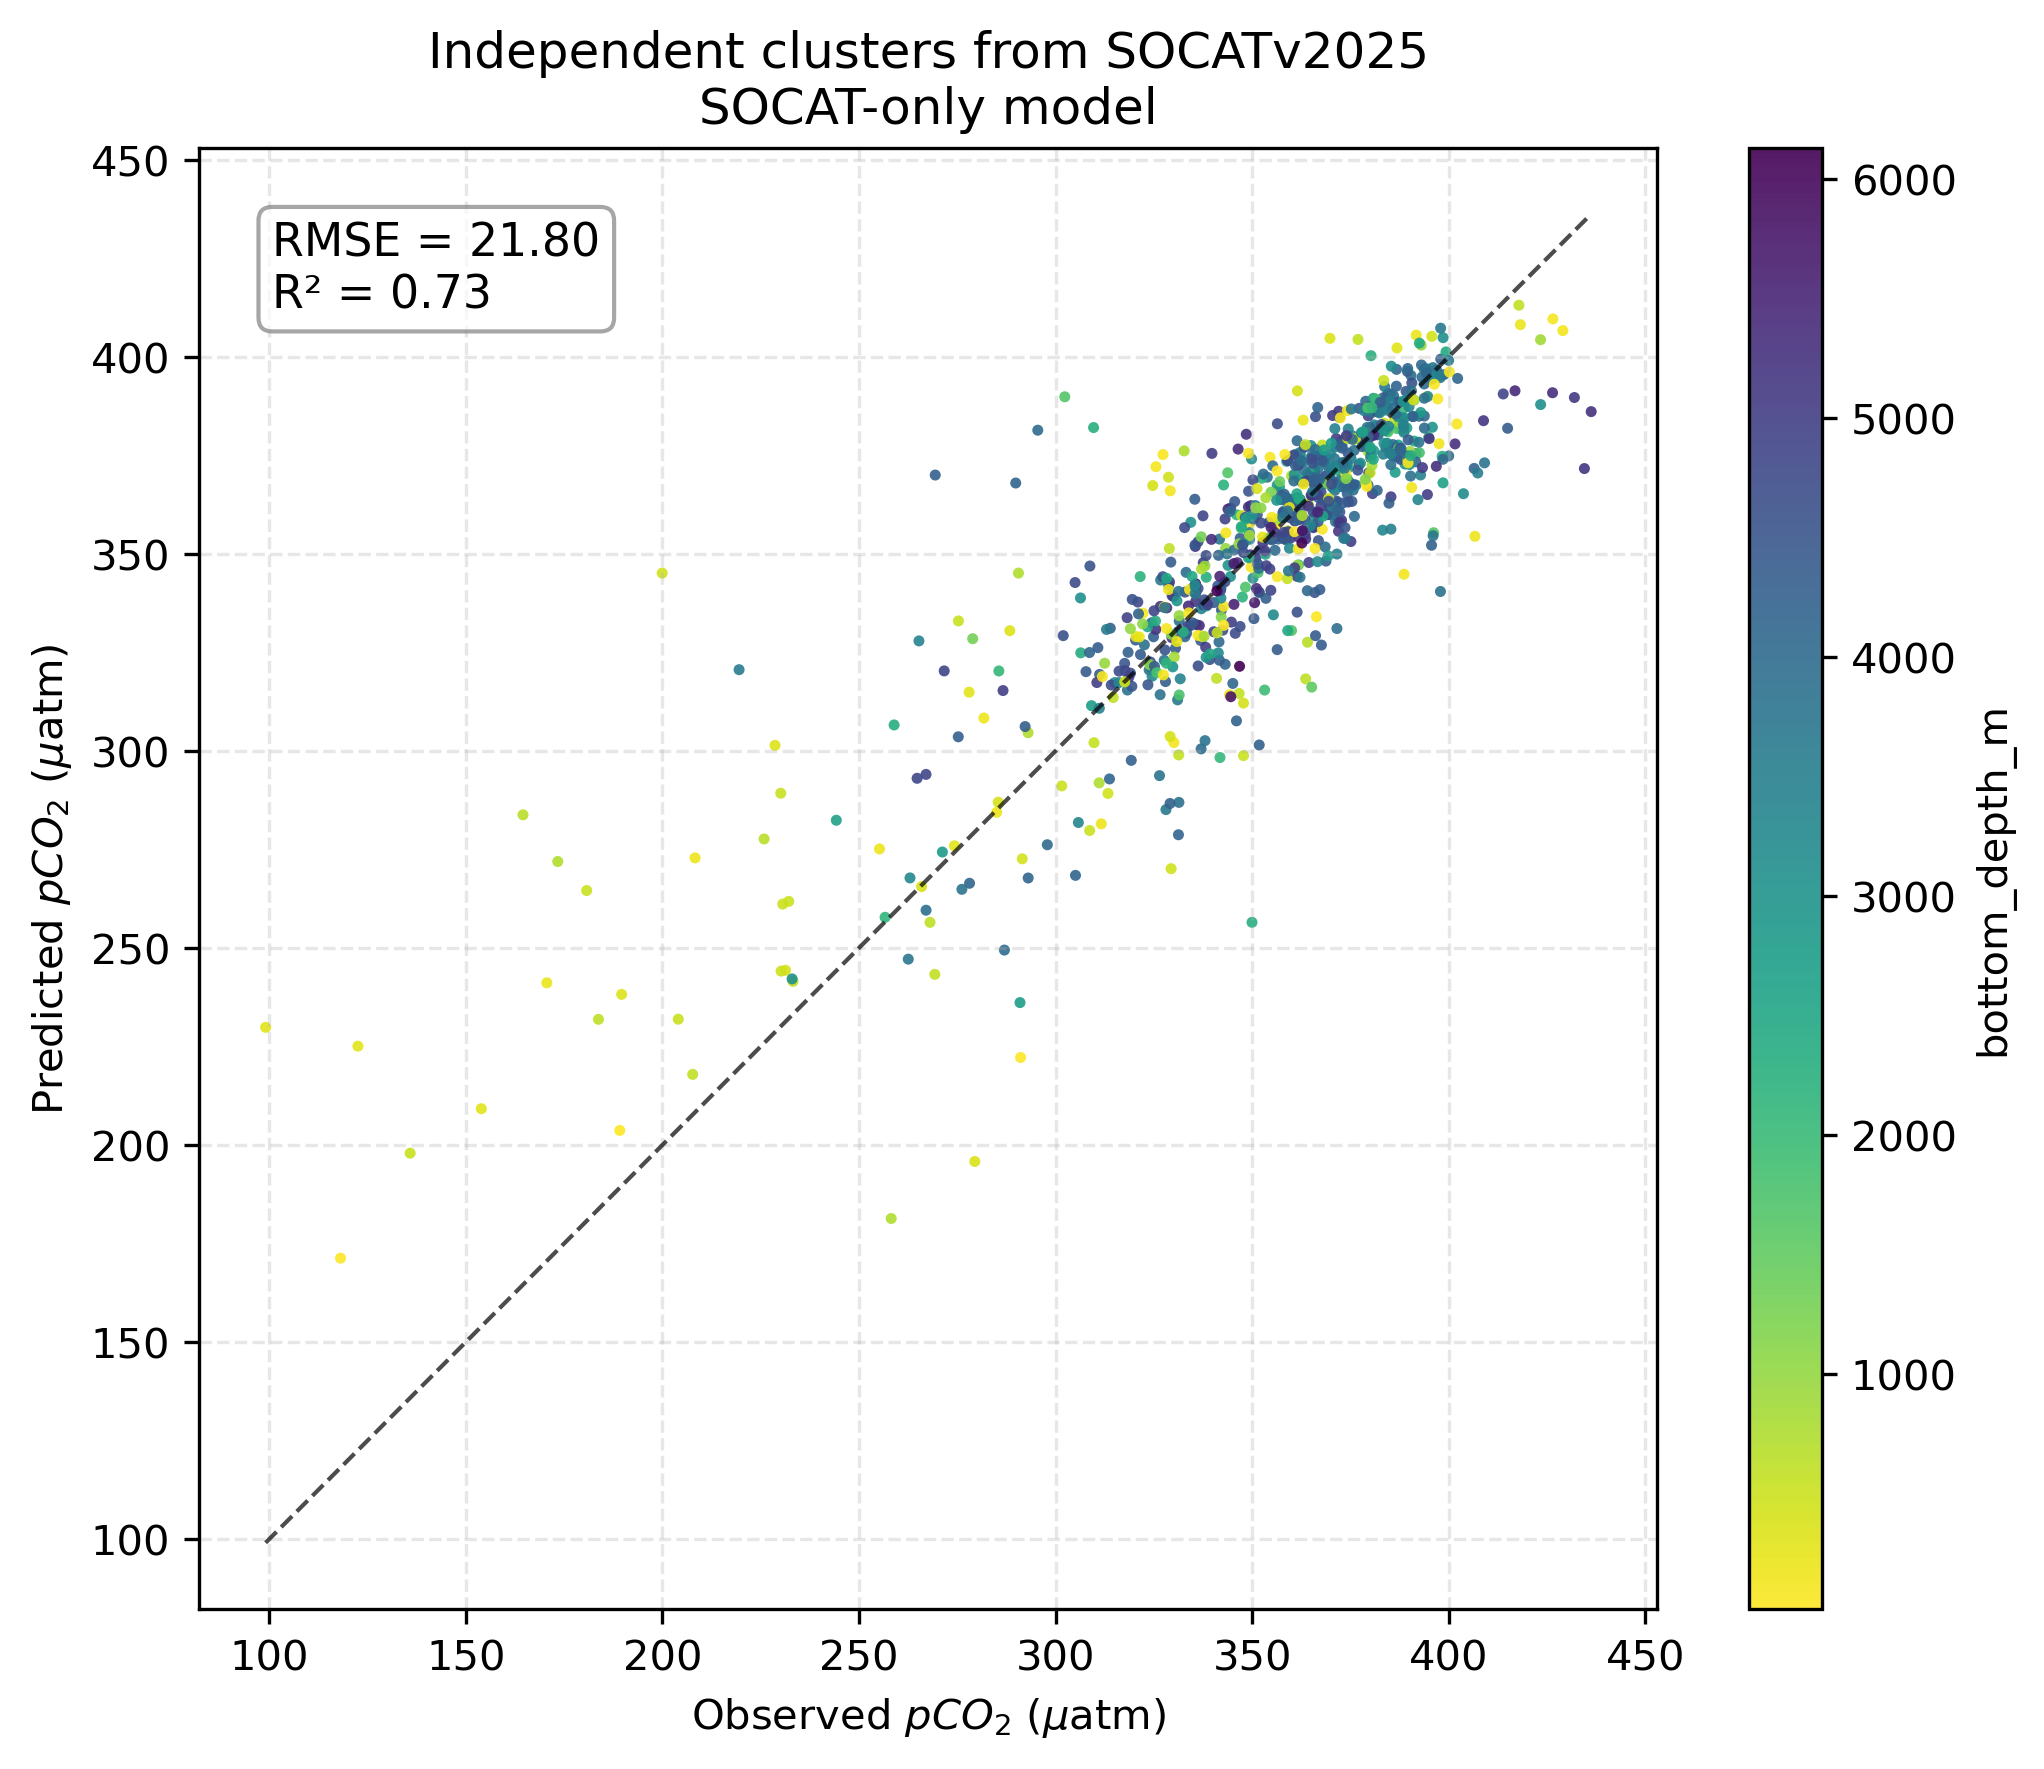

In [128]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

color_var = 'bottom_depth_m'

fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

sc = ax.scatter(
    df['pco2'],
    df['ensemble_pco2_pred'],
    c=df[color_var],
    cmap='viridis_r',
    s=7,
    alpha=0.9,
    edgecolor='none'
)

ax.set_xlabel("Observed $pCO_2$ ($\mu$atm)")
ax.set_ylabel("Predicted $pCO_2$ ($\mu$atm)")
ax.set_title(f"Independent clusters from SOCATv2025\nSOCAT-only model")
ax.grid(True, ls='--', alpha=0.3)

# 1:1 line
min_pco2 = min(df['pco2'].min(), df['ensemble_pco2_pred'].min())
max_pco2 = max(df['pco2'].max(), df['ensemble_pco2_pred'].max())
ax.plot([min_pco2, max_pco2], [min_pco2, max_pco2], 'k--', lw=1, alpha=0.7, label="1:1 line")

# Colorbar
cbar = fig.colorbar(sc, ax=ax, label=color_var)

# Calculate metrics
rmse = mean_squared_error(df['pco2'], df['ensemble_pco2_pred'], squared=False)
r2 = r2_score(df['pco2'], df['ensemble_pco2_pred'])

# Stats box (RMSE + R²)
stats_text = f"RMSE = {rmse:.2f}\nR² = {r2:.2f}"

ax.text(
    0.05, 0.95, stats_text,
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
)

fig.tight_layout()
plt.show()


In [129]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from sklearn.metrics import mean_squared_error

x = df['pco2'].values
y = df['ensemble_pco2_pred'].values

# Compute the point density
xy = np.vstack([x, y])
density = gaussian_kde(xy)(xy)

# Sort the points by density so that dense points are plotted on top
idx = density.argsort()
x, y, density = x[idx], y[idx], density[idx]


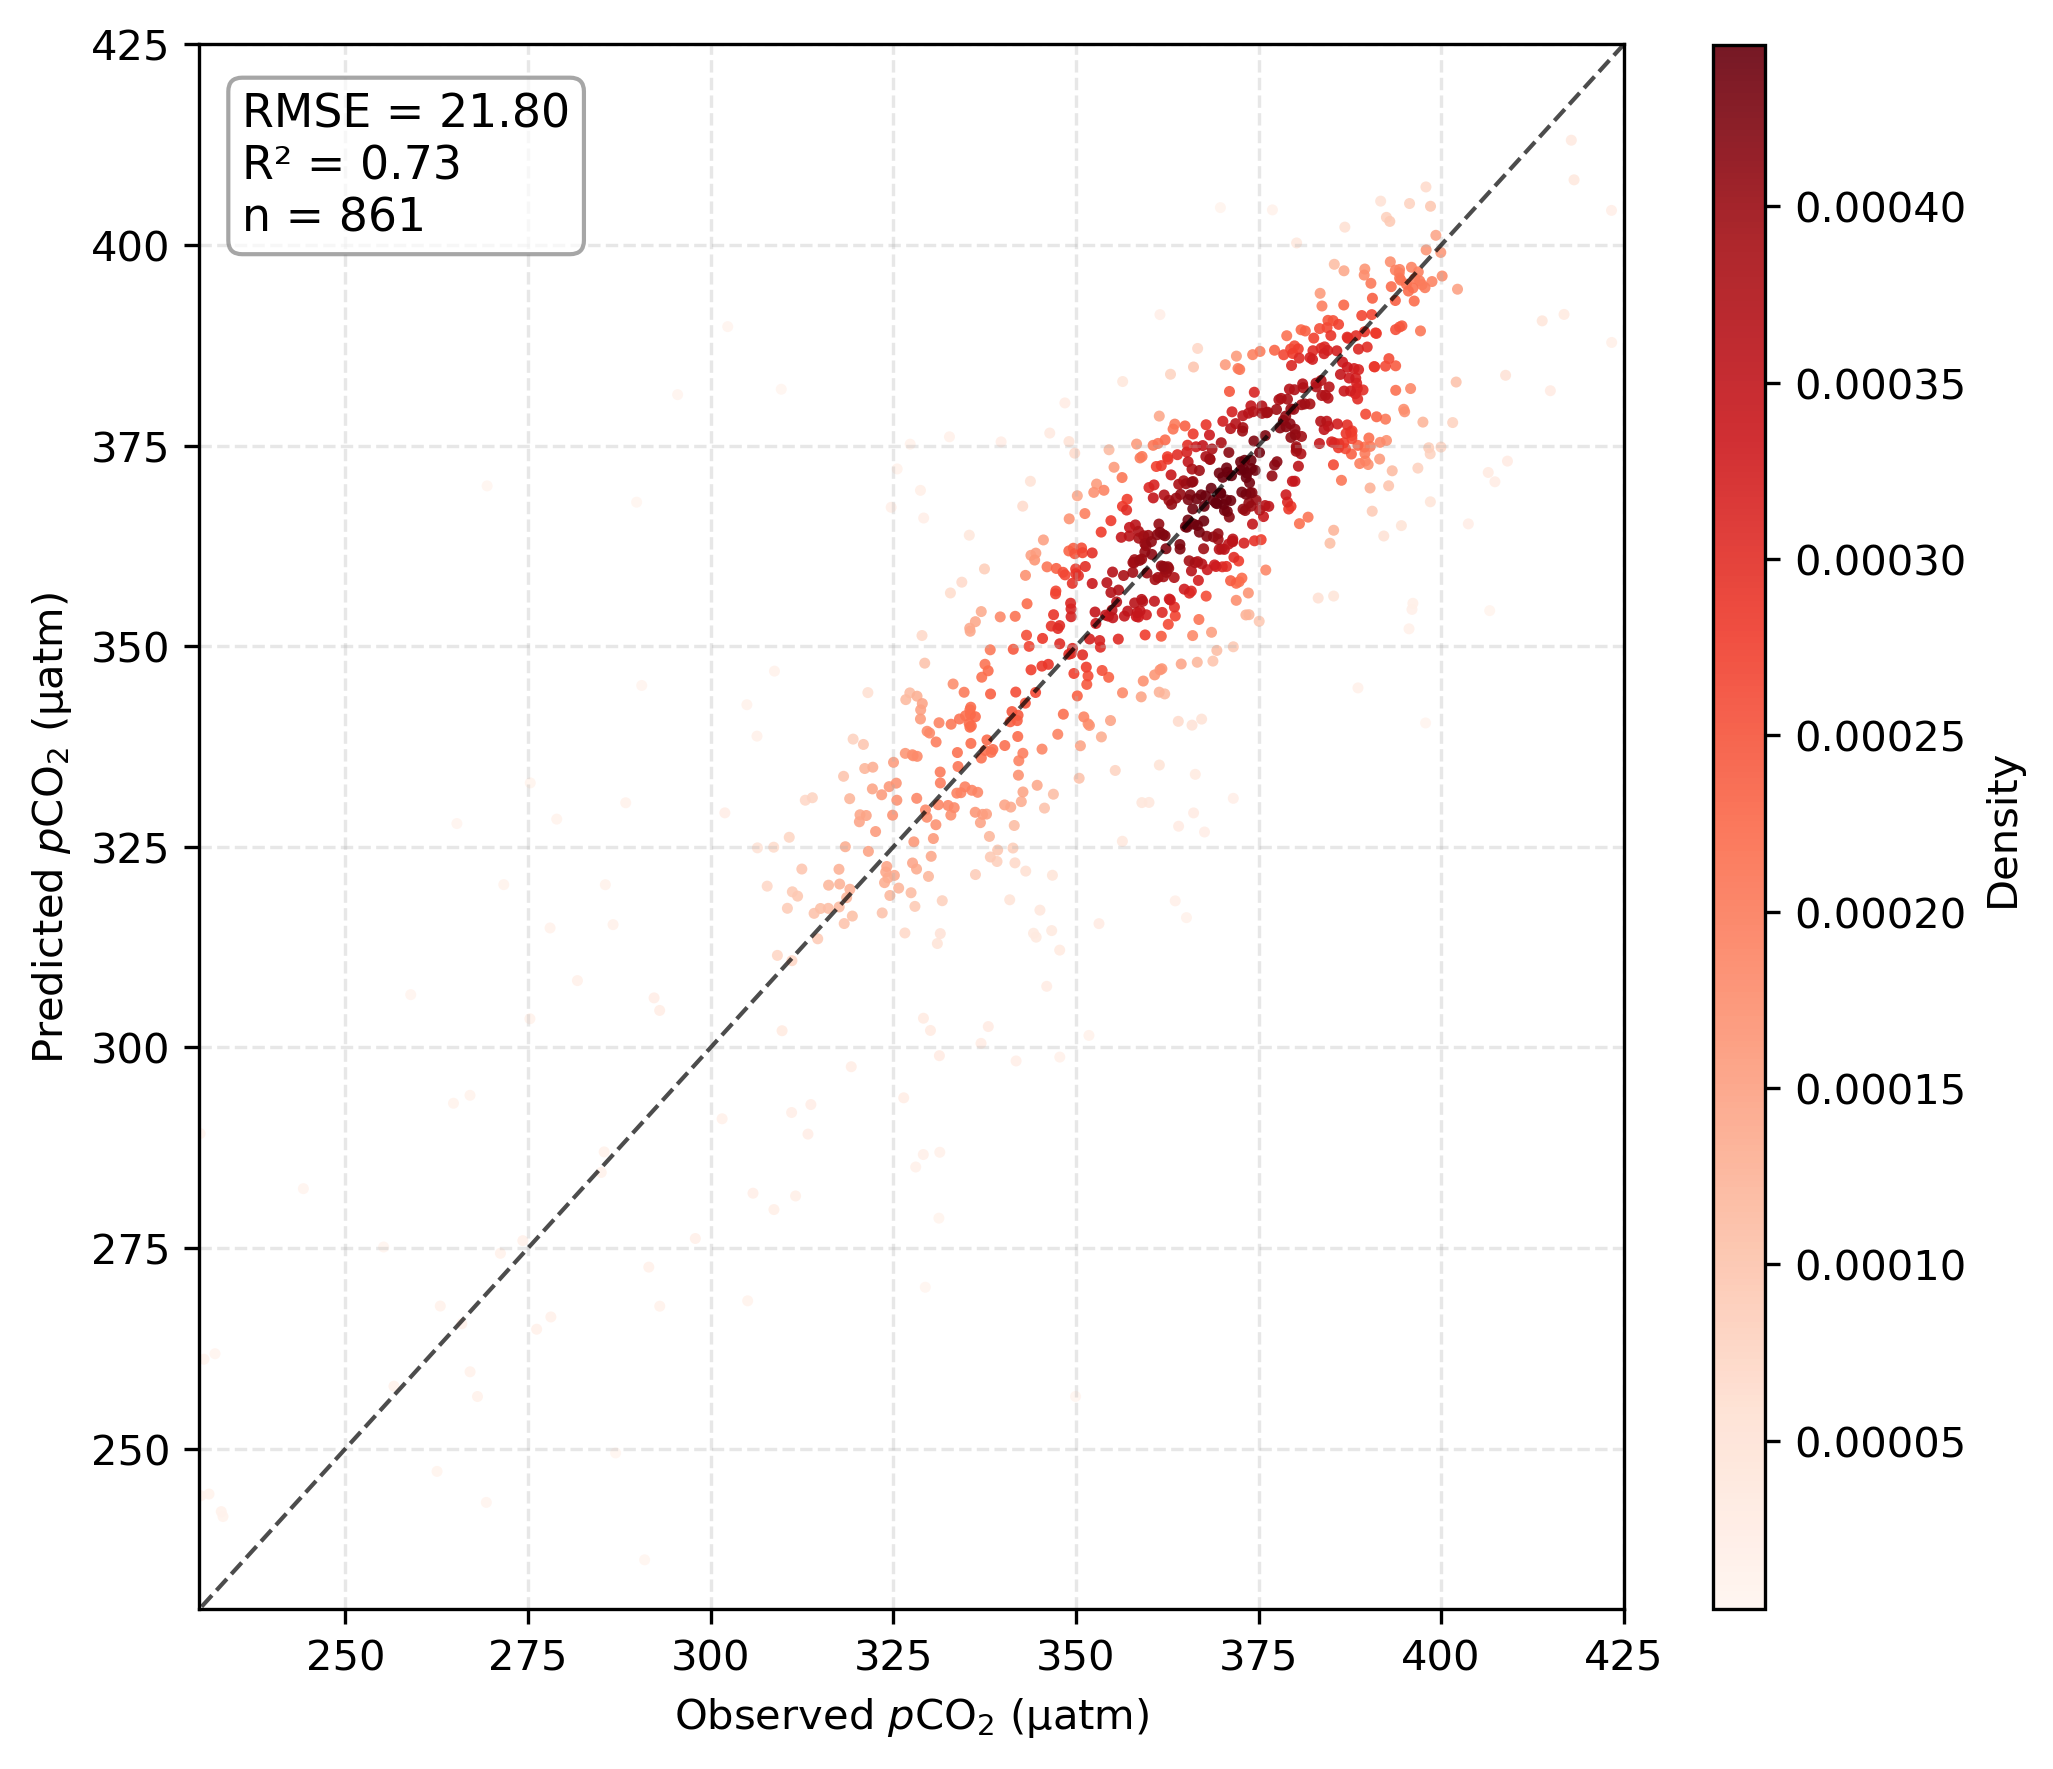

In [130]:
fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

sc = ax.scatter(
    x, y,
    c=density,
    s=7,
    alpha=0.9,
    edgecolor='none',
    cmap='Reds' 
)

ax.set_xlabel(r"Observed $p\mathrm{CO}_2$ $\mathrm{(\mu atm)}$")
ax.set_ylabel(r"Predicted $p\mathrm{CO}_2$ $\mathrm{(\mu atm)}$")
ax.grid(True, ls='--', alpha=0.3)

# 1:1 line
min_pco2 = min(x.min(), y.min())
max_pco2 = max(x.max(), y.max())
ax.plot([min_pco2, max_pco2], [min_pco2, max_pco2], 'k--', lw=1, alpha=0.7)

ax.set_xlim(230, 425)
ax.set_ylim(230, 425)

# Colorbar
cbar = fig.colorbar(sc, ax=ax, label='Density', aspect=30)

# Calculate metrics
rmse = mean_squared_error(x, y, squared=False)
r2 = r2_score(x, y)
n = len(df)

# Stats box with RMSE + R² + n
stats_text = f"RMSE = {rmse:.2f}\nR² = {r2:.2f}\nn = {n}"

ax.text(
    0.03, 0.97, stats_text,
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.7)
)

fig.tight_layout()
fig.savefig("figs/pco2_density_scatter.png", dpi=300, bbox_inches='tight')
plt.show()


In [131]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from sklearn.metrics import mean_squared_error

# --- Season assignment function ---
def get_season(month):
    if month in [12, 1, 2]:
        return 'Summer'
    elif month in [3, 4, 5]:
        return 'Autumn'
    elif month in [6, 7, 8]:
        return 'Winter'
    elif month in [9, 10, 11]:
        return 'Spring'

# --- Convert month_center to datetime ---
df['month_center'] = pd.to_datetime(df['month_center'], errors='coerce')

# --- Extract month ---
df['month'] = df['month_center'].dt.month

# --- Assign season ---
df['season'] = df['month'].apply(get_season)

# --- Prepare for global KDE scaling ---
all_x = df['pco2'].values
all_y = df['ensemble_pco2_pred'].values

xy = np.vstack([all_x, all_y])
all_density = gaussian_kde(xy)(xy)

global_vmin = all_density.min()
global_vmax = all_density.max()

print("Done: global density range =", global_vmin, global_vmax)


Done: global density range = 2.265341835500429e-06 0.00044584033738217854


/tmp/ipykernel_2016048/2121267159.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


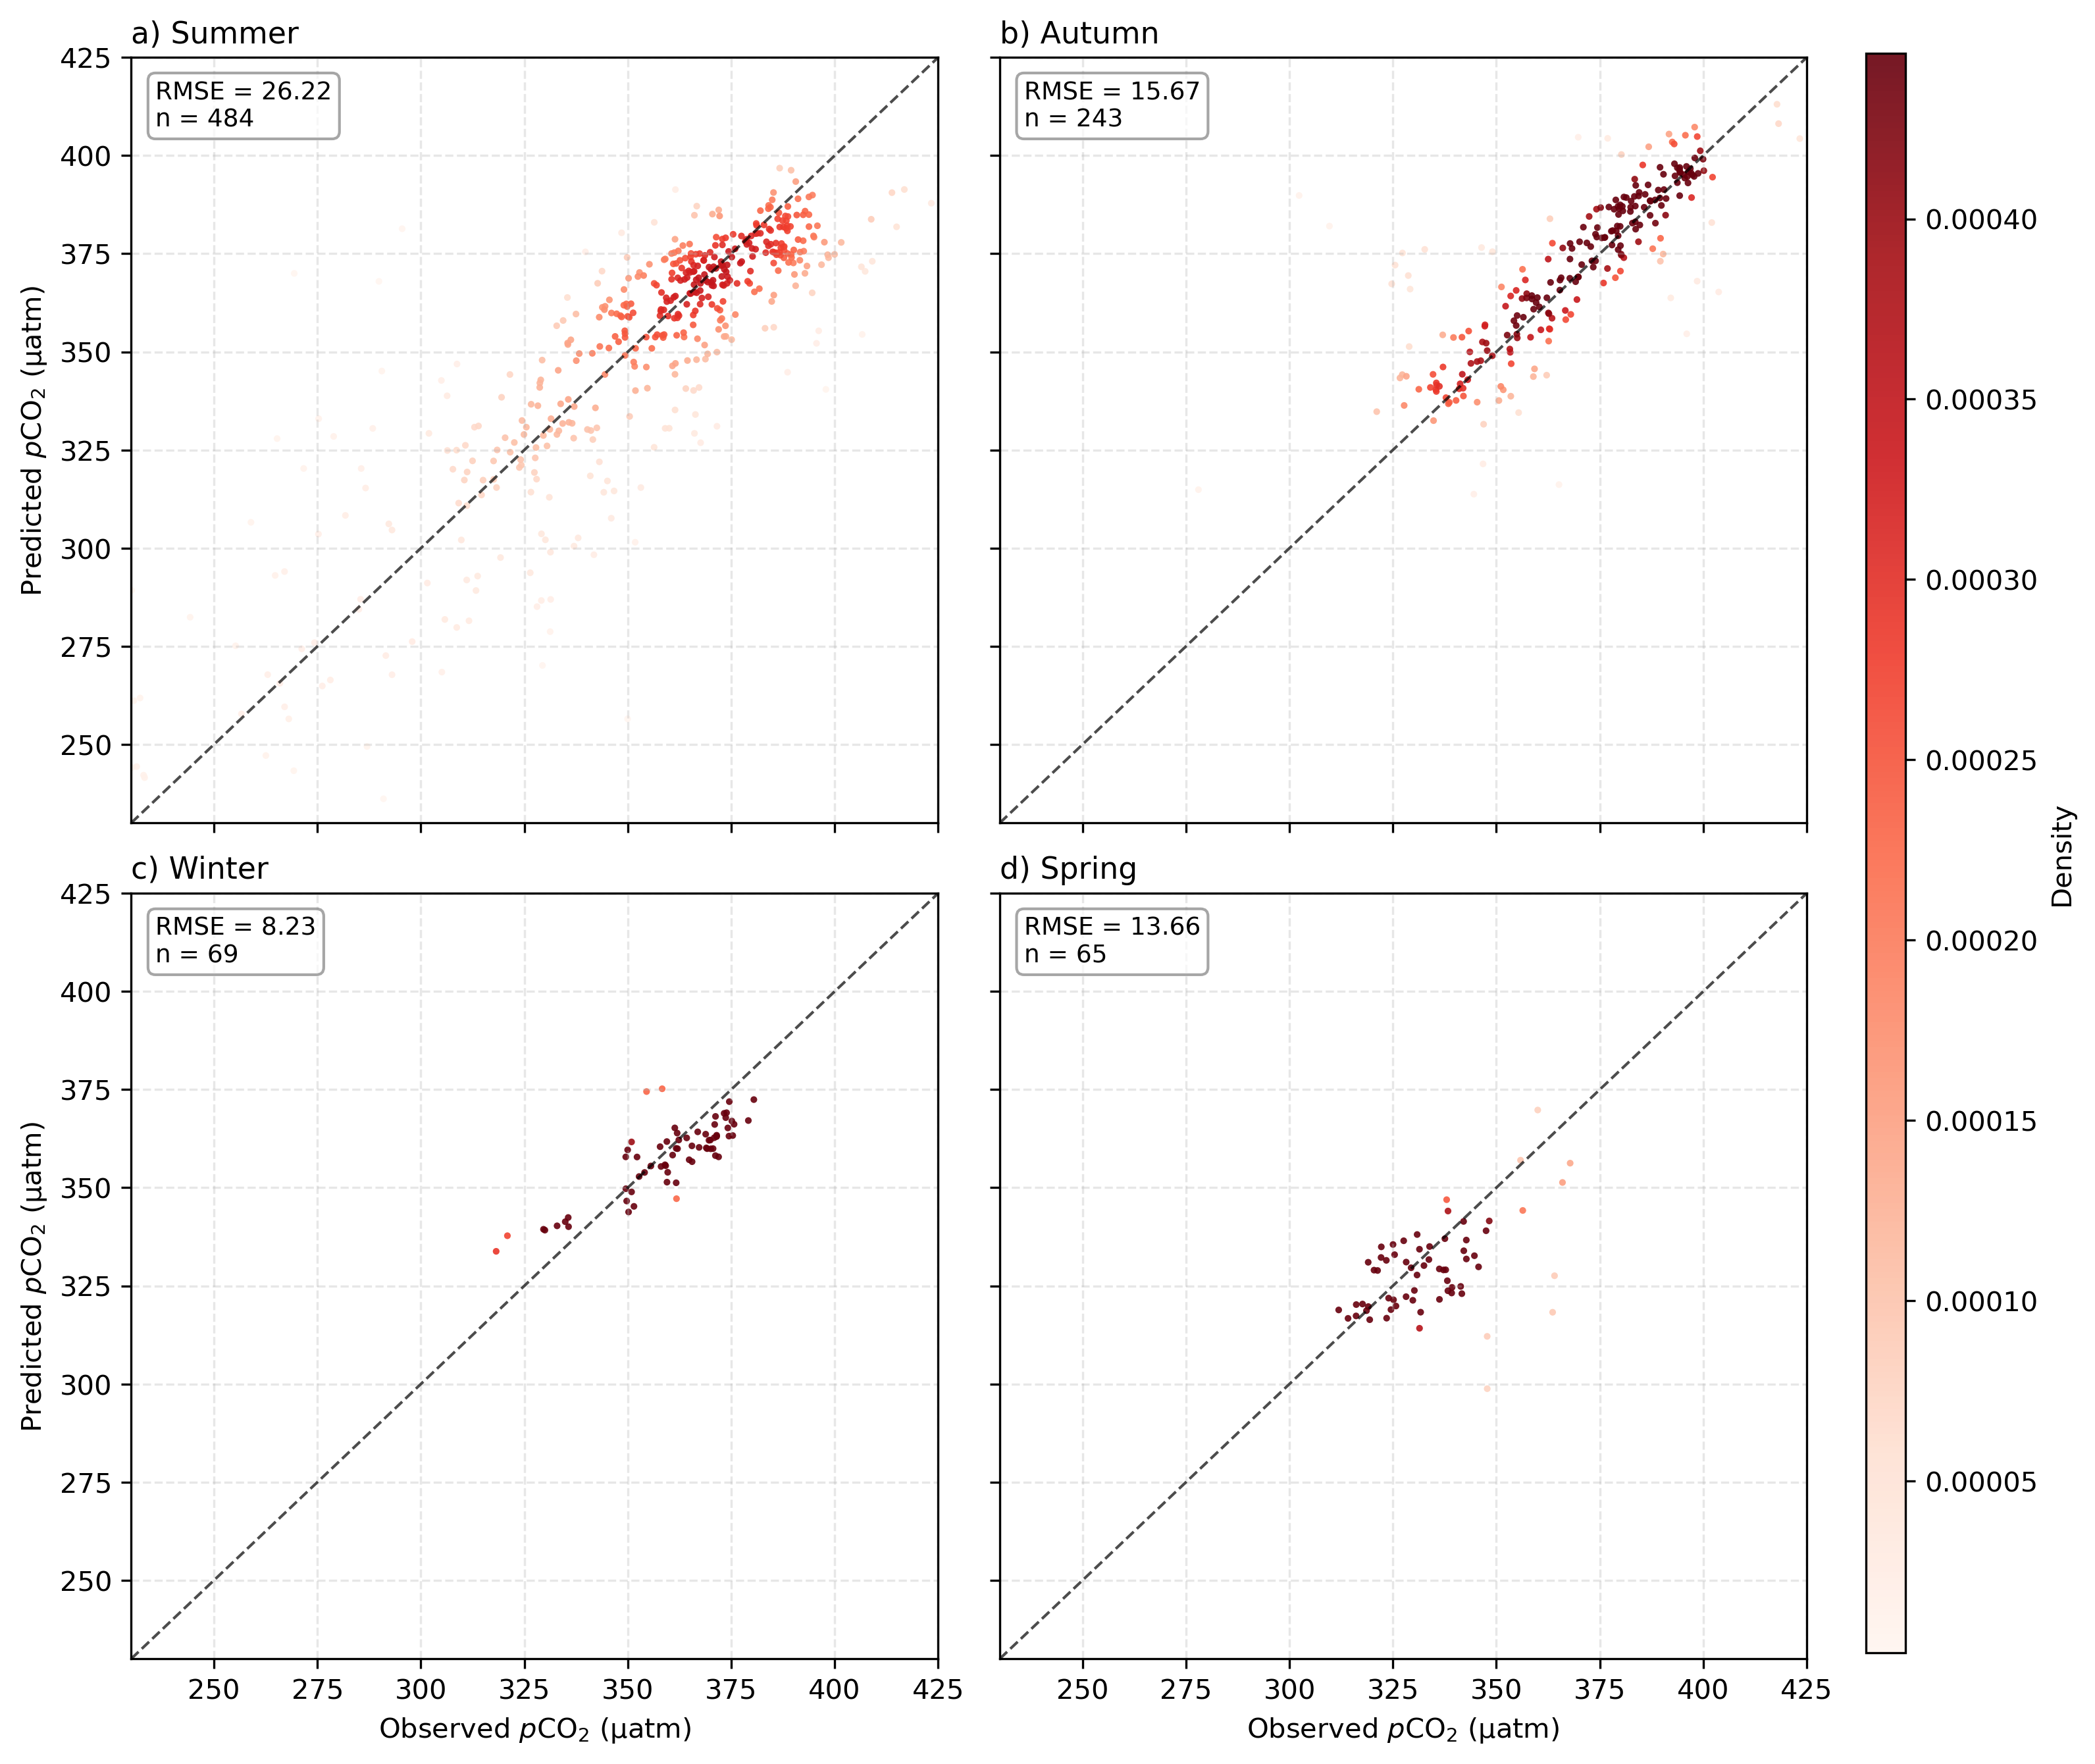

In [132]:
# Prepare subplot grid
fig, axs = plt.subplots(2, 2, figsize=(10, 9), dpi=300, sharex=True, sharey=True)
axs = axs.flatten()
season_order = ['Summer', 'Autumn', 'Winter', 'Spring']
letters = ['a) Summer', 'b) Autumn', 'c) Winter', 'd) Spring']
xlim = ylim = (230, 425)

for i, season in enumerate(season_order):
    ax = axs[i]
    data = df[df['season'] == season]

    x = data['pco2'].values
    y = data['ensemble_pco2_pred'].values

    # Compute raw (non-log) KDE density
    xy = np.vstack([x, y])
    density = gaussian_kde(xy)(xy)
    idx = density.argsort()
    x, y, density = x[idx], y[idx], density[idx]

    # Scatter plot
    sc = ax.scatter(
        x, y,
        c=density,
        s=6,
        alpha=0.9,
        edgecolor='none',
        cmap='Reds',
        vmin=global_vmin,
        vmax=global_vmax
    )

    # Axes setup
    if i % 2 == 0:
        ax.set_ylabel(r"Predicted $p\mathrm{CO}_2$ $\mathrm{(\mu atm)}$")
    if i >= 2:
        ax.set_xlabel(r"Observed $p\mathrm{CO}_2$ $\mathrm{(\mu atm)}$")

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.grid(True, ls='--', alpha=0.3)

    # 1:1 line
    ax.plot([xlim[0], xlim[1]], [ylim[0], ylim[1]], 'k--', lw=1, alpha=0.7)

    # Calculate metrics for the season
    rmse = mean_squared_error(x, y, squared=False)
    n = len(x)

    # Stats box: top-right corner of each subplot
    stats_text = f"RMSE = {rmse:.2f}\nn = {n:}"
    ax.text(
        0.03, 0.97, stats_text,  # x near left, y near top
        transform=ax.transAxes,
        fontsize=9,
        va='top',
        ha='left',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
    )

    # Top-left corner label
    ax.text(
        0, 1.05, letters[i],
        transform=ax.transAxes,
        fontsize=11,
        va='top',
        ha='left'
    )

# Add an axis for the colorbar manually (x0, y0, width, height in figure coordinates)
cbar_ax = fig.add_axes([0.95, 0.068, 0.02, 0.9])  # [left, bottom, width, height]

# Create the colorbar in that axis
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('Density')

fig.tight_layout()
fig.subplots_adjust(right=0.92)
fig.savefig("figs/pco2_density_by_season.png", dpi=300, bbox_inches='tight')
plt.show()